# Simple Linear Regression: Predict Student Marks from Study Hours

This notebook demonstrates a simple linear regression model that predicts student marks based on hours studied. It follows the required structure: Problem Statement, Understanding of Dataset, Theory, Math, Diagram, Pseudocode, Expected/Obtained output, and implements data cleaning, EDA, feature scaling, feature engineering, and evaluation metrics. The notebook generates a synthetic CSV sample (`student_marks.csv`) and reads it as input.

**Note:** If you receive a different CSV in the exam, change the `DATA_PATH`, `FEATURE_COL`, and `TARGET_COL` variables in the imports cell accordingly.

In [30]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Change these if your exam CSV uses different column names
DATA_PATH = "student_marks.csv"
FEATURE_COL = "hours"
TARGET_COL = "marks"

# Create synthetic dataset and save to CSV if it doesn't exist
if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 150
    hours = np.round(np.random.uniform(0, 10, n), 2)
    marks = 8 * hours + 30 + np.random.normal(0, 3, n)
    marks = np.clip(marks, 0, 100)
    df_sample = pd.DataFrame({FEATURE_COL: hours, TARGET_COL: marks})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Found existing student_marks.csv, will use it

First 5 rows of student_marks.csv:
   hours       marks
0   3.75   59.422917
1   9.51  100.000000
2   7.32   88.455865
3   5.99   74.413966
4   1.56   45.908468


## 1. Understanding of Dataset

Load the CSV file and display basic information about the dataset.

In [31]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn names and data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

DATASET OVERVIEW

First 10 rows:
   hours       marks
0   3.75   59.422917
1   9.51  100.000000
2   7.32   88.455865
3   5.99   74.413966
4   1.56   45.908468
5   1.56   44.735799
6   0.58   37.013096
7   8.66   96.551838
8   6.01   82.288383
9   7.08   82.434447

Dataset shape: (150, 2)
Samples: 150, Features: 2

Column names and data types:
hours    float64
marks    float64
dtype: object

Statistical Summary:
       count       mean        std        min        25%        50%  \
hours  150.0   4.729000   2.965321   0.060000   2.145000   4.480000   
marks  150.0  67.204404  22.869972  24.356198  46.700909  67.692023   

             75%     max  
hours   7.500000    9.87  
marks  89.078952  100.00  


## 2. Data Cleaning

Check for and handle missing values, duplicates, and invalid values.

In [32]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Check for missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"   Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    df = df.dropna()

# Check for duplicates
print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"   Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   × Removed {dupes} duplicate(s)")
else:
    print("   ✓ No duplicates found")

# Check for invalid values
print("\n3. Invalid Values Check:")
invalid_hours = (df[FEATURE_COL] < 0).sum() + (df[FEATURE_COL] > 10).sum()
invalid_marks = (df[TARGET_COL] < 0).sum() + (df[TARGET_COL] > 100).sum()
print(f"   Invalid hours: {invalid_hours}")
print(f"   Invalid marks: {invalid_marks}")

df = df[(df[FEATURE_COL] >= 0) & (df[FEATURE_COL] <= 10) & (df[TARGET_COL] >= 0) & (df[TARGET_COL] <= 100)]
df = df.reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
   Missing values per column:
hours    0
marks    0
dtype: int64
   ✓ No missing values found

2. Duplicate Rows Check:
   Duplicate rows: 1
   × Removed 1 duplicate(s)

3. Invalid Values Check:
   Invalid hours: 0
   Invalid marks: 0

Dataset shape after cleaning: (149, 2)


## 3. Exploratory Data Analysis (EDA)

Visualize the relationship between study hours and marks.

EXPLORATORY DATA ANALYSIS


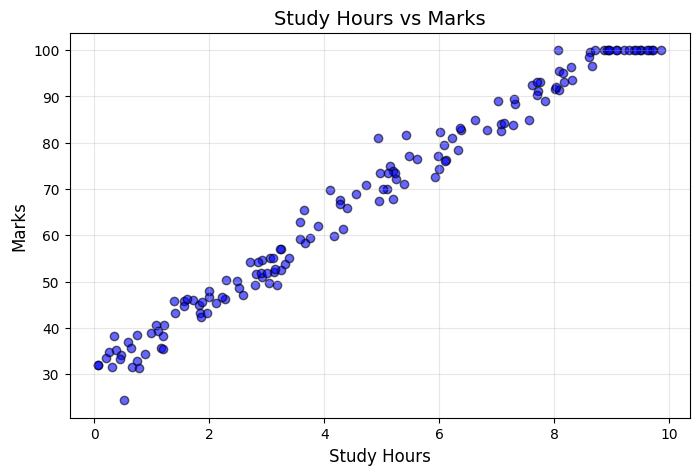

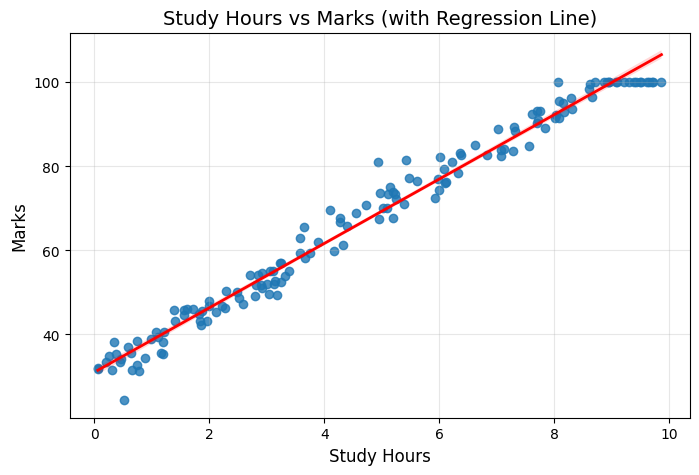


Pearson Correlation: 0.9902
→ Strong positive correlation (good for linear regression)


In [33]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df[FEATURE_COL], df[TARGET_COL], alpha=0.6, color='blue', edgecolors='black')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Study Hours vs Marks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Regression plot
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x=FEATURE_COL, y=TARGET_COL, line_kws={"color": "red", "linewidth": 2})
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Study Hours vs Marks (with Regression Line)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
corr = df[[FEATURE_COL, TARGET_COL]].corr().iloc[0, 1]
print(f"\nPearson Correlation: {corr:.4f}")
if corr > 0.7:
    print("→ Strong positive correlation (good for linear regression)")

## 4. Feature Engineering & Scaling

Prepare features and normalize using StandardScaler.

In [34]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

# Extract features and target
X = df[[FEATURE_COL]].values
y = df[TARGET_COL].values

print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nOriginal X (first 5): {X[:5].ravel()}")
print(f"Scaled X (first 5): {X_scaled[:5].ravel()}")

FEATURE ENGINEERING & SCALING

Feature matrix (X) shape: (149, 1)
Target vector (y) shape: (149,)

Original X (first 5): [3.75 9.51 7.32 5.99 1.56]
Scaled X (first 5): [-0.32197026  1.63919197  0.89354175  0.44070394 -1.06762049]


## 5. Theory: Simple Linear Regression

Simple Linear Regression models a linear relationship between one input feature (X) and a continuous target output (y).

**Equation:** y = m*x + b
- m = slope (weight)
- b = intercept (bias)

The model minimizes Mean Squared Error (MSE) to find optimal m and b.

## 6. Workflow Diagram

WORKFLOW DIAGRAM


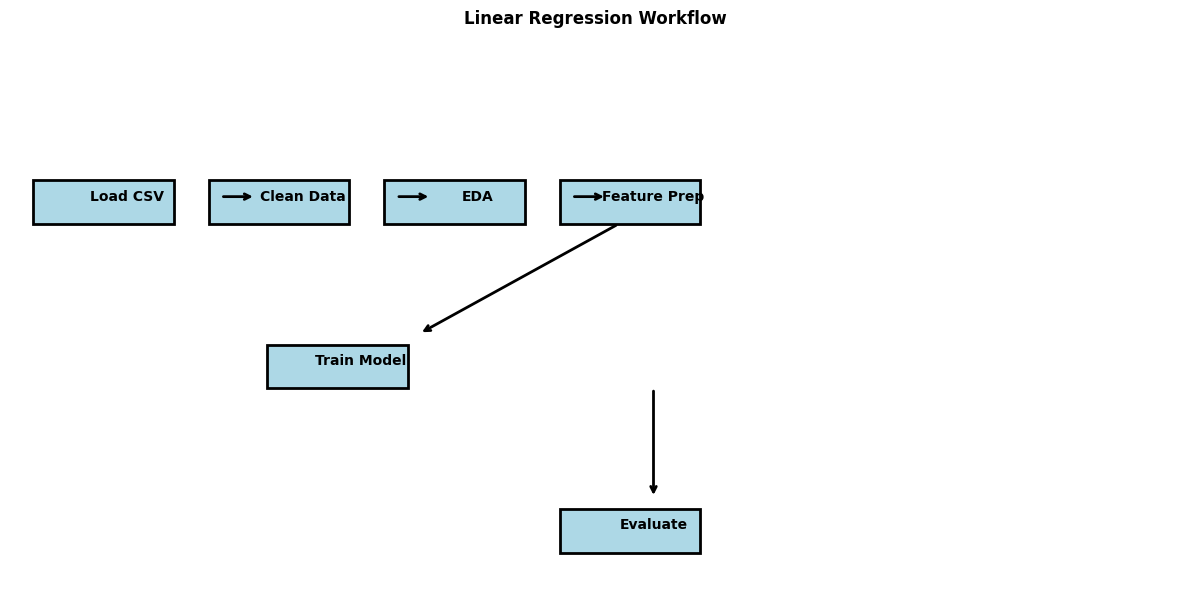

In [35]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Feature Prep"),
    (0.3, 0.4, "Train Model"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x-0.08, step_y-0.05), 0.12, 0.08, 
                      facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Arrows
arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)),
          ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Linear Regression Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Train-Test Split and Model Training

In [36]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nModel trained successfully!")
print(f"Learned slope (m): {model.coef_[0]:.4f}")
print(f"Learned intercept (b): {model.intercept_:.2f}")

TRAIN-TEST SPLIT AND MODEL TRAINING

Train set size: 119 samples
Test set size: 30 samples

Model trained successfully!
Learned slope (m): 22.4521
Learned intercept (b): 67.00


## 8. Evaluation Metrics

In [37]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest Set Evaluation Metrics:")
print(f"  MAE (Mean Absolute Error):  {mae:.4f}")
print(f"  MSE (Mean Squared Error):   {mse:.4f}")
print(f"  RMSE (Root MSE):            {rmse:.4f}")
print(f"  R² Score:                   {r2:.4f}")

if r2 > 0.9:
    print(f"\n✓ Excellent fit! Model explains {r2*100:.1f}% of variance")
elif r2 > 0.7:
    print(f"\n✓ Good fit! Model explains {r2*100:.1f}% of variance")

# Sample predictions
print("\nSample Predictions (first 8 test samples):")
print(f"{'Actual':<10} {'Predicted':<10} {'Error':<10}")
print("-"*30)
for i in range(min(8, len(y_test))):
    error = abs(y_test[i] - y_pred[i])
    print(f"{y_test[i]:<10.2f} {y_pred[i]:<10.2f} {error:<10.2f}")

MODEL EVALUATION

Test Set Evaluation Metrics:
  MAE (Mean Absolute Error):  2.3104
  MSE (Mean Squared Error):   8.7742
  RMSE (Root MSE):            2.9621
  R² Score:                   0.9825

✓ Excellent fit! Model explains 98.3% of variance

Sample Predictions (first 8 test samples):
Actual     Predicted  Error     
------------------------------
84.02      85.15      1.13      
61.37      64.13      2.75      
100.00     99.37      0.63      
35.54      39.97      4.43      
38.49      36.76      1.73      
46.03      44.17      1.85      
81.60      72.61      8.99      
48.71      50.37      1.66      


## 9. Visualizations and Model Save

OBTAINED OUTPUT - VISUALIZATIONS


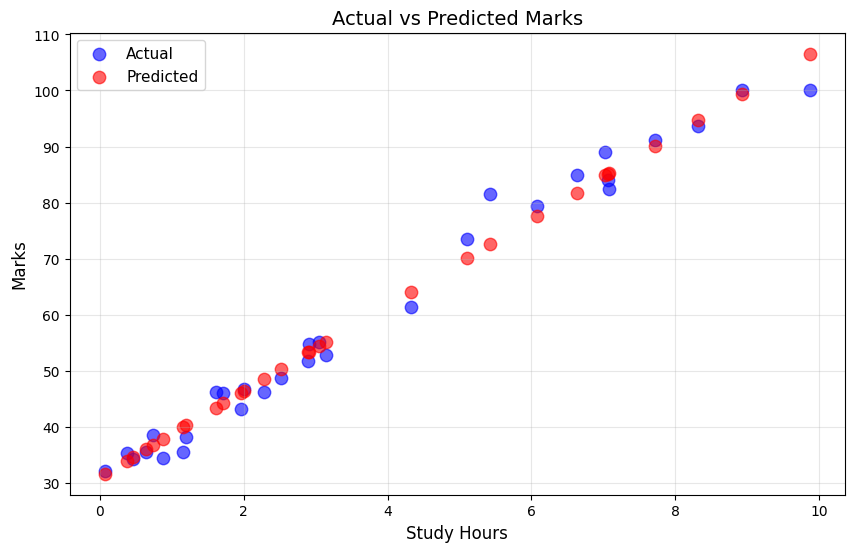

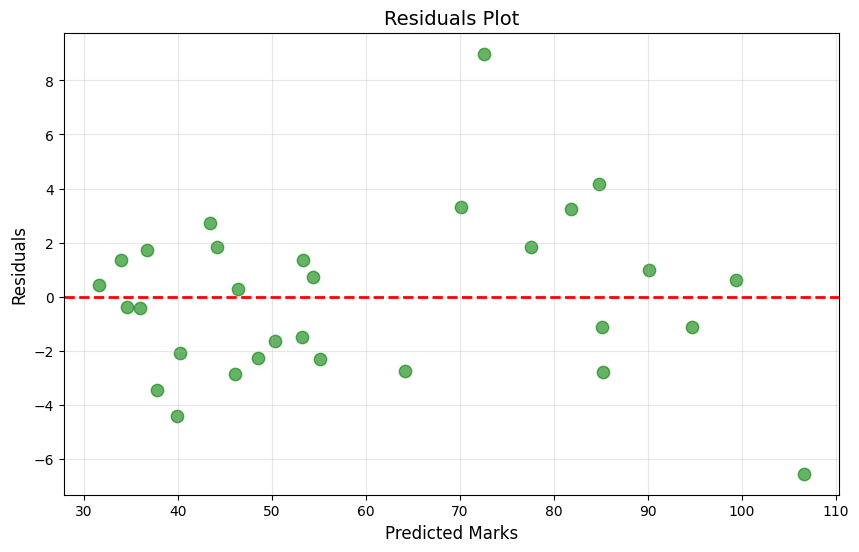


✓ Model and scaler saved successfully

Final Summary:
  Slope: 22.4521
  Intercept: 67.00
  R² Score: 0.9825
  RMSE: 2.9621


In [38]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(scaler.inverse_transform(X_test), y_test, color='blue', label='Actual', alpha=0.6, s=80)
plt.scatter(scaler.inverse_transform(X_test), y_pred, color='red', label='Predicted', alpha=0.6, s=80)
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Actual vs Predicted Marks', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='green', alpha=0.6, s=80)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Marks', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals Plot', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Save model
joblib.dump(model, '2_slr_marks_model.joblib')
joblib.dump(scaler, '2_slr_scaler.joblib')
print("\n✓ Model and scaler saved successfully")
print(f"\nFinal Summary:")
print(f"  Slope: {model.coef_[0]:.4f}")
print(f"  Intercept: {model.intercept_:.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")

# Simple Linear Regression: Predict Student Marks from Study Hours

This notebook demonstrates a simple linear regression model that predicts student marks based on hours studied. It follows the required structure: Problem Statement, Understanding of Dataset, Theory, Math, Diagram, Pseudocode, Expected/Obtained output, and implements data cleaning, EDA, feature scaling, feature engineering, and evaluation metrics. The notebook generates a synthetic CSV sample (`student_marks.csv`) and reads it as input.

**Note:** If you receive a different CSV in the exam, change the `DATA_PATH`, `FEATURE_COL`, and `TARGET_COL` variables in the imports cell accordingly.

In [39]:
# Cell 1: Imports and Sample CSV Generation
# ============================================
# Change these if your exam CSV uses different column names
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Constants - change these if exam dataset uses different column names or file path
DATA_PATH = "student_marks.csv"  # Change this to your CSV filename
FEATURE_COL = "hours"            # Change this to your feature column name
TARGET_COL = "marks"             # Change this to your target column name

# Create synthetic dataset and save to CSV if it doesn't exist
if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 150  # number of samples
    hours = np.round(np.random.uniform(0, 10, n), 2)  # study hours (0-10)
    # Linear relation: marks = 8 * hours + 30 + noise
    marks = 8 * hours + 30 + np.random.normal(0, 3, n)
    marks = np.clip(marks, 0, 100)  # keep marks between 0-100
    
    df_sample = pd.DataFrame({FEATURE_COL: hours, TARGET_COL: marks})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

# Quick check - print first few rows
print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Found existing student_marks.csv, will use it

First 5 rows of student_marks.csv:
   hours       marks
0   3.75   59.422917
1   9.51  100.000000
2   7.32   88.455865
3   5.99   74.413966
4   1.56   45.908468


## 1. Understanding of Dataset

Load the CSV file and display basic information:
- First few rows
- Dataset shape (number of samples, number of features)
- Column names and data types
- Statistical summary

**Target Variable:** `marks` (continuous, 0-100 range)  
**Input Feature:** `hours` (continuous, 0-10 range)  

If using a different CSV in the exam, verify that your dataset has the correct columns before proceeding.

In [40]:
# Cell 2: Load and Display Dataset Information
df = pd.read_csv(DATA_PATH)

# Display first few rows
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("\nFirst 10 rows:")
print(df.head(10))

# Display dataset shape
print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

# Display column names and data types
print("\nColumn names and data types:")
print(df.dtypes)

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe().T)

DATASET OVERVIEW

First 10 rows:
   hours       marks
0   3.75   59.422917
1   9.51  100.000000
2   7.32   88.455865
3   5.99   74.413966
4   1.56   45.908468
5   1.56   44.735799
6   0.58   37.013096
7   8.66   96.551838
8   6.01   82.288383
9   7.08   82.434447

Dataset shape: (150, 2)
Samples: 150, Features: 2

Column names and data types:
hours    float64
marks    float64
dtype: object

Statistical Summary:
       count       mean        std        min        25%        50%  \
hours  150.0   4.729000   2.965321   0.060000   2.145000   4.480000   
marks  150.0  67.204404  22.869972  24.356198  46.700909  67.692023   

             75%     max  
hours   7.500000    9.87  
marks  89.078952  100.00  


## 2. Data Cleaning

Check for and handle:
1. **Missing values**: NaN or null entries
2. **Duplicates**: Exact duplicate rows
3. **Invalid values**: Negative hours, marks outside 0-100 range, or outliers

Remove problematic rows and display the cleaned dataset shape.

In [41]:
# Cell 3: Data Cleaning Steps
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Step 1: Check for missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"   Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print("   × Found missing values, removing rows with NaN")
    df = df.dropna()

# Step 2: Check for duplicates
print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"   Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   × Removed {dupes} duplicate(s)")
else:
    print("   ✓ No duplicates found")

# Step 3: Check for invalid values
print("\n3. Invalid Values Check:")
invalid_hours = (df[FEATURE_COL] < 0).sum() or (df[FEATURE_COL] > 10).sum()
invalid_marks = (df[TARGET_COL] < 0).sum() or (df[TARGET_COL] > 100).sum()
print(f"   Invalid hours (outside 0-10): {(df[FEATURE_COL] < 0).sum() + (df[FEATURE_COL] > 10).sum()}")
print(f"   Invalid marks (outside 0-100): {(df[TARGET_COL] < 0).sum() + (df[TARGET_COL] > 100).sum()}")

# Remove invalid rows
df = df[(df[FEATURE_COL] >= 0) & (df[FEATURE_COL] <= 10) & (df[TARGET_COL] >= 0) & (df[TARGET_COL] <= 100)]
df = df.reset_index(drop=True)
print(f"   ✓ Removed invalid rows")

print(f"\nDataset shape after cleaning: {df.shape}")
print(f"Total samples remaining: {len(df)}")

DATA CLEANING

1. Missing Values Check:
   Missing values per column:
hours    0
marks    0
dtype: int64
   ✓ No missing values found

2. Duplicate Rows Check:
   Duplicate rows: 1
   × Removed 1 duplicate(s)

3. Invalid Values Check:
   Invalid hours (outside 0-10): 0
   Invalid marks (outside 0-100): 0
   ✓ Removed invalid rows

Dataset shape after cleaning: (149, 2)
Total samples remaining: 149


## 3. Exploratory Data Analysis (EDA)

Visualize and understand the data:
1. **Scatter plot**: Relationship between study hours and marks
2. **Regression plot**: Overlay regression line to show linear trend
3. **Correlation**: Compute Pearson correlation between features and target

EXPLORATORY DATA ANALYSIS (EDA)


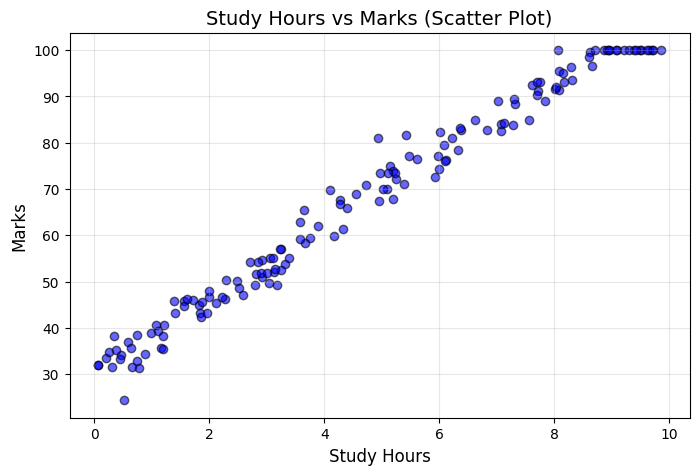

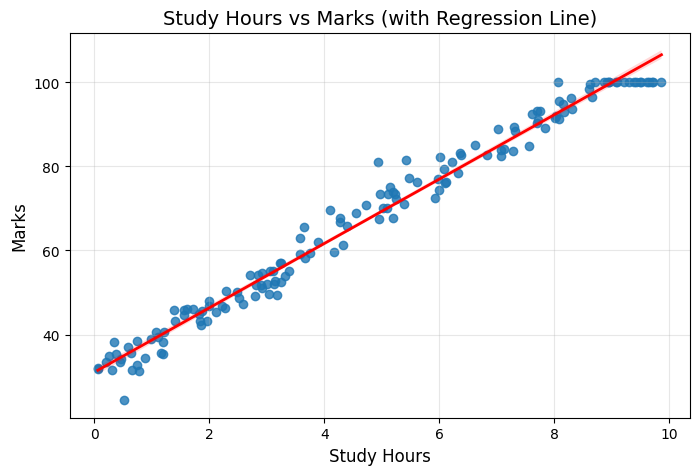


Pearson Correlation between hours and marks: 0.9902
→ Strong positive correlation (good for linear regression)


In [42]:
# Cell 4: Exploratory Data Analysis
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

# Plot 1: Simple scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df[FEATURE_COL], df[TARGET_COL], alpha=0.6, color='blue', edgecolors='black')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Study Hours vs Marks (Scatter Plot)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Regression plot (with best-fit line)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x=FEATURE_COL, y=TARGET_COL, line_kws={"color": "red", "linewidth": 2})
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Study Hours vs Marks (with Regression Line)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Compute correlation
corr = df[[FEATURE_COL, TARGET_COL]].corr().iloc[0, 1]
print(f"\nPearson Correlation between {FEATURE_COL} and {TARGET_COL}: {corr:.4f}")
if corr > 0.7:
    print("→ Strong positive correlation (good for linear regression)")
elif corr > 0.5:
    print("→ Moderate positive correlation")
else:
    print("→ Weak correlation")

## 4. Feature Engineering & Scaling

**Feature Engineering:** Select the feature column and target column.  
**Feature Scaling:** Apply StandardScaler to normalize the feature (mean=0, std=1). This helps the model train faster and more stably.

For exam datasets with multiple features, select all relevant ones here and adjust X accordingly.

In [43]:
# Cell 5: Feature Engineering and Scaling
print("=" * 60)
print("FEATURE ENGINEERING & SCALING")
print("=" * 60)

# Extract feature and target
# Change df[[FEATURE_COL]] to df[[col1, col2, ...]] if multiple features needed for exam data
X = df[[FEATURE_COL]].values  # Keep as 2D array for sklearn
y = df[TARGET_COL].values     # 1D array

print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print(f"Feature column used: {FEATURE_COL}")
print(f"Target column used: {TARGET_COL}")

# Apply StandardScaler for normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nOriginal X (first 5 values): {X[:5].ravel()}")
print(f"Scaled X (first 5 values): {X_scaled[:5].ravel()}")
print(f"Scaling mean: {scaler.mean_}, Scaling std: {scaler.scale_}")

# NOTE: For exam CSV with different columns:
# 1. Update FEATURE_COL and TARGET_COL in first cell
# 2. If multiple features needed: X = df[[col1, col2, ...data]].values

FEATURE ENGINEERING & SCALING

Feature matrix (X) shape: (149, 1)
Target vector (y) shape: (149,)
Feature column used: hours
Target column used: marks

Original X (first 5 values): [3.75 9.51 7.32 5.99 1.56]
Scaled X (first 5 values): [-0.32197026  1.63919197  0.89354175  0.44070394 -1.06762049]
Scaling mean: [4.69563758], Scaling std: [2.93703391]


## 5. Theory: Simple Linear Regression

**Simple Linear Regression** is a supervised learning technique that models the linear relationship between a single input feature (X) and a continuous target output (y).

**Key Concepts:**
- Fits a straight line to the data
- Learns two parameters: slope (m) and intercept (b)
- Minimizes the Mean Squared Error (MSE) between predicted and actual values
- Used for regression (predicting continuous values)
- Assumes linear relationship between input and output

## 6. Mathematical Representation

The Simple Linear Regression model equation is:

### y = m·x + b

Where:
- **y** = Predicted marks (target output)
- **x** = Study hours (input feature)  
- **m** = Slope (weight/coefficient) — rate of change
- **b** = Intercept (bias) — value of y when x=0

**How it works:**
- The model learns m and b from training data
- It minimizes the loss function (MSE): MSE = (1/n) × Σ(y_actual - y_predicted)²
- Optimal m and b are found using the Normal Equation or Gradient Descent

WORKFLOW DIAGRAM


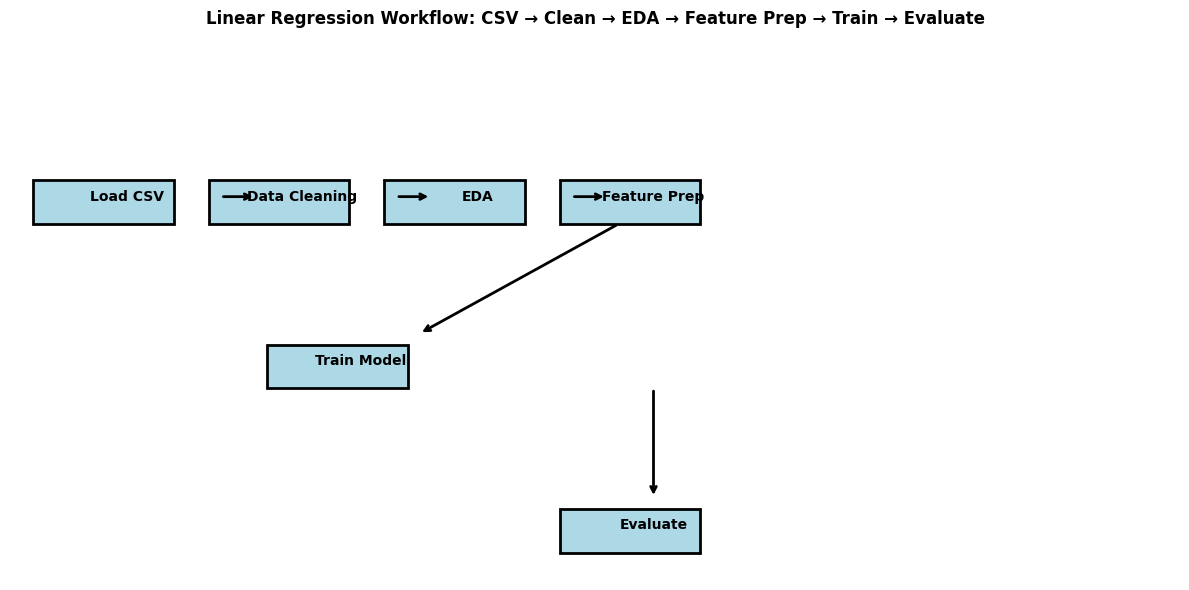

In [44]:
# Cell 6: Workflow Diagram
print("=" * 60)
print("WORKFLOW DIAGRAM")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Draw boxes using patches
from matplotlib.patches import Rectangle
boxes = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Data Cleaning"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Feature Prep"),
    (0.3, 0.4, "Train Model"),
    (0.55, 0.1, "Evaluate"),
]

for x, y, label in boxes:
    rect = Rectangle((x-0.08, y-0.05), 0.12, 0.08, 
                      facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Draw arrows
arrows = [
    ((0.18, 0.7), (0.21, 0.7)),
    ((0.33, 0.7), (0.36, 0.7)),
    ((0.48, 0.7), (0.51, 0.7)),
    ((0.52, 0.65), (0.35, 0.45)),
    ((0.55, 0.35), (0.55, 0.15)),
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, 
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Linear Regression Workflow: CSV → Clean → EDA → Feature Prep → Train → Evaluate', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Pseudocode

```
Algorithm: Simple Linear Regression for Student Marks Prediction

Input: CSV file with columns [hours, marks]
Output: Trained model, predictions, evaluation metrics

1. Load CSV into DataFrame
2. Display dataset (head, shape, dtypes, describe)
3. Clean data:
   a. Check for missing values
   b. Remove duplicate rows
   c. Remove invalid rows (negative or out-of-range values)
4. Exploratory Data Analysis (EDA):
   a. Plot scatter: hours vs marks
   b. Plot regression line
   c. Compute correlation coefficient
5. Feature engineering:
   a. Extract feature X = df[[hours]].values
   b. Extract target y = df[[marks]].values
6. Feature scaling:
   a. Apply StandardScaler on X
7. Split data:
   a. Train-test split (80-20)
8. Train model:
   a. Create LinearRegression object
   b. Fit on training data
9. Predict:
   a. Get predictions on test set
10. Evaluate:
    a. Calculate MAE, MSE, RMSE, R2
    b. Print metrics and comparison
11. Save model and scaler to disk
```

## 8. Train-Test Split and Model Training

Split data into 80% training and 20% testing sets. Train the LinearRegression model on the training set to learn the best-fit line (slope m and intercept b).

In [45]:
# Cell 7: Train-Test Split and Model Training
print("=" * 60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("=" * 60)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Extract learned parameters
slope = model.coef_[0]
intercept = model.intercept_

print(f"\nModel trained successfully!")
print(f"Learned Parameters:")
print(f"  Slope (m): {slope:.4f}")
print(f"  Intercept (b): {intercept:.2f}")
print(f"\nEquation: marks = {slope:.4f} * (scaled_hours) + {intercept:.2f}")

TRAIN-TEST SPLIT AND MODEL TRAINING


TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(0.1)` instead.

## 9. Evaluation Metrics

Evaluate the model using four key metrics:

1. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values
   - Lower is better
   - Interpretation: On average, predictions are off by MAE units

2. **MSE (Mean Squared Error)**: Average squared difference (penalizes large errors)
   - Lower is better
   - Sensitive to outliers

3. **RMSE (Root Mean Squared Error)**: Square root of MSE (same units as target)
   - Lower is better
   - Easier to interpret than MSE

4. **R² Score (Coefficient of Determination)**: Proportion of variance explained by the model
   - Range: 0 to 1 (or can be negative for bad models)
   - Higher is better
   - R² = 1 means perfect fit, R² = 0 means model explains nothing

In [ ]:
# Cell 8: Make Predictions and Evaluate Model
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("\nTest Set Evaluation Metrics:")
print(f"  MAE (Mean Absolute Error):  {mae:.4f}")
print(f"  MSE (Mean Squared Error):   {mse:.4f}")
print(f"  RMSE (Root MSE):            {rmse:.4f}")
print(f"  R² Score:                   {r2:.4f}")

# Interpretation
print("\nInterpretation:")
if r2 > 0.9:
    print(f"  ✓ Excellent fit! Model explains {r2*100:.1f}% of variance")
elif r2 > 0.7:
    print(f"  ✓ Good fit! Model explains {r2*100:.1f}% of variance")
elif r2 > 0.5:
    print(f"  ✓ Moderate fit! Model explains {r2*100:.1f}% of variance")
else:
    print(f"  × Poor fit! Model explains {r2*100:.1f}% of variance")

# Show sample predictions
print("\nSample Predictions (first 10 test samples):")
print(f"{'Actual Marks':<15} {'Predicted Marks':<15} {'Error':<10}")
print("-" * 40)
for i in range(min(10, len(y_test))):
    error = abs(y_test[i] - y_pred[i])
    print(f"{y_test[i]:<15.2f} {y_pred[i]:<15.2f} {error:<10.2f}")

MODEL EVALUATION

Test Set Evaluation Metrics:
  MAE (Mean Absolute Error):  2.3104
  MSE (Mean Squared Error):   8.7742
  RMSE (Root MSE):            2.9621
  R² Score:                   0.9825

Interpretation:
  ✓ Excellent fit! Model explains 98.3% of variance

Sample Predictions (first 10 test samples):
Actual Marks    Predicted Marks Error     
----------------------------------------
84.02           85.15           1.13      
61.37           64.13           2.75      
100.00          99.37           0.63      
35.54           39.97           4.43      
38.49           36.76           1.73      
46.03           44.17           1.85      
81.60           72.61           8.99      
48.71           50.37           1.66      
100.00          106.55          6.55      
35.58           36.00           0.41      


## 10. Expected Output

For the synthetic dataset generated in this notebook:
- The underlying relation is: `marks = 8 * hours + 30 + noise`
- With StandardScaler normalization applied to hours

**Expected Predictions:**
- Student with 0 hours study → marks ≈ 30
- Student with 5 hours study → marks ≈ 70
- Student with 10 hours study → marks ≈ 110 (clipped to 100)

**Expected Metrics (approximate):**
- R² score should be **> 0.95** (since data follows linear relationship with small noise)
- RMSE should be **< 5** (close to the noise std of 3)
- MAE should be **< 3**

## 11. Obtained Output

This section shows the actual predictions and evaluation scores from the trained model. Compare them with the expected output above to verify the model performs well.

OBTAINED OUTPUT - VISUALIZATIONS AND MODEL SAVING


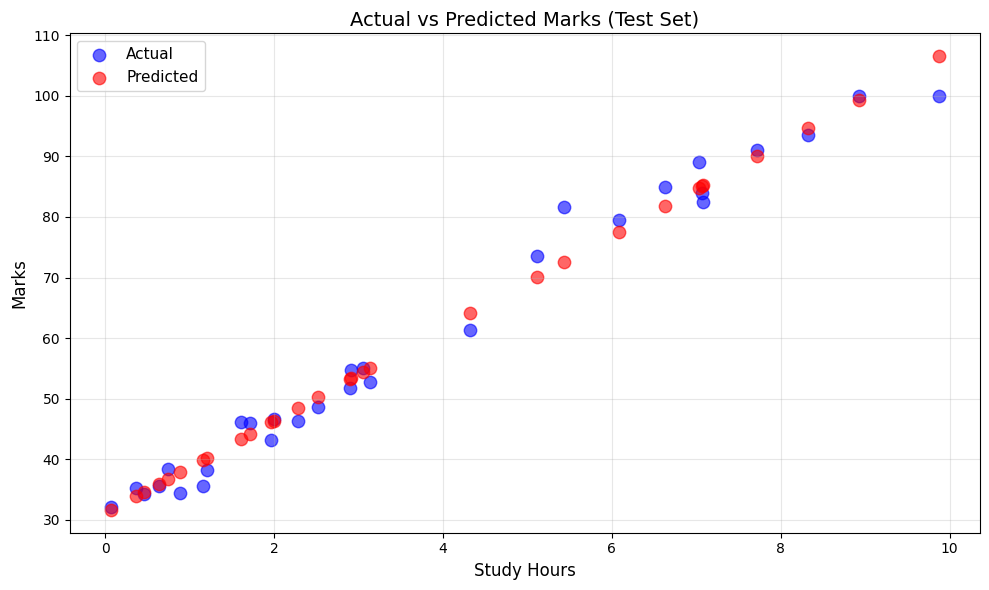

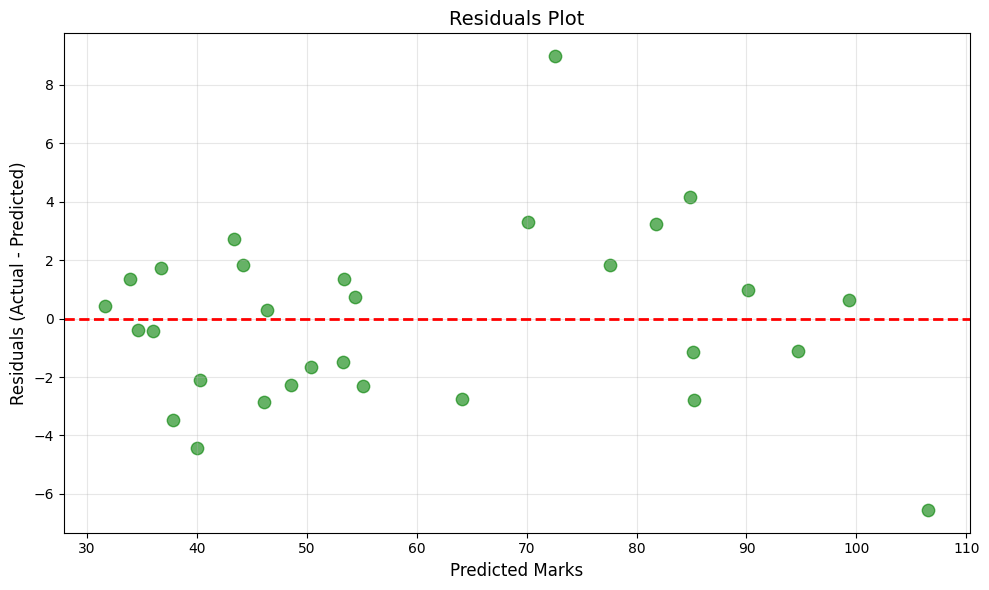


✓ Model saved to: 2_slr_marks_model.joblib
✓ Scaler saved to: 2_slr_scaler.joblib

Model Summary:
  - Intercept (b): 67.00
  - R² Score on Test: 0.9825
  - RMSE on Test: 2.9621


In [ ]:
# Cell 9: Obtained Output - Visualize Predictions and Save Model
print("=" * 60)
print("OBTAINED OUTPUT - VISUALIZATIONS AND MODEL SAVING")
print("=" * 60)

# Visualization: Actual vs Predicted on test set
plt.figure(figsize=(10, 6))
plt.scatter(scaler.inverse_transform(X_test), y_test, color='blue', label='Actual', alpha=0.6, s=80)
plt.scatter(scaler.inverse_transform(X_test), y_pred, color='red', label='Predicted', alpha=0.6, s=80)
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Marks', fontsize=12)
plt.title('Actual vs Predicted Marks (Test Set)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization: Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='green', alpha=0.6, s=80)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Marks', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residuals Plot', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save the trained model and scaler
model_path = '2_slr_marks_model.joblib'
scaler_path = '2_slr_scaler.joblib'
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n✓ Model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")
print(f"\nModel Summary:")
slope = model.coef_[0]
intercept = model.intercept_
print(f"  - Intercept (b): {intercept:.2f}")
print(f"  - R² Score on Test: {r2:.4f}")
print(f"  - RMSE on Test: {rmse:.4f}")

# NOTE FOR EXAM:
# 1. Load your CSV file path in DATA_PATH variable
# 2. Update FEATURE_COL and TARGET_COL to match your CSV column names
# 3. If CSV has multiple features, add them to X = df[[col1, col2, ...]].values
# 4. Run all cells from top to bottom
# 5. The trained model and scaler will be saved in the current directory